## Derivative-Constrained PINN — Gibson–Schwartz convenience-yield inversion

Ported from a colleague's DC-PINN calibration notebook, originally built for SABR / Dupire-local-vol option calibration. Kept as-is because it's problem-agnostic: the network architecture, the optax optimizer, and the WAMOL loss-balancing machinery (self-adaptive per-point weights + gradient-norm loss balancing). Stripped entirely: every Black-Scholes / SABR / Dupire-local-vol function (`bs`, `black`, `d1_`, `d2_`, `lv_sqr`, `SabrVolHagan`, `bs_iv`, the arbitrage-heatmap and vol-surface plots, `get_data`'s SABR sampler) — none of it applies to Gibson-Schwartz.

**One exception to "everything ported into this notebook":** the closed-form GS coefficients (`GSParams`, `B_coeff`, `A_coeff`) are imported from `gs_wamol.physics.gibson_schwartz` rather than re-typed here. Per `CLAUDE.md` sec. 3, those coefficients are exact and verified against Schwartz (1997) eqs. (18)–(20) — retyping them risks a silent transcription bug, and `monte_carlo.ipynb` already depends on that exact module.

**Loss terms now come from `docs/mathematical_derivations-5.pdf`, not from my own guess.** An earlier version of this notebook improvised an "OU drift-consistency" physics term because the network's exact I/O contract hadn't been pinned down yet — that guess turned out to be wrong on two counts (it collapsed `delta_hat` to a flat line at `alpha_P` in testing, and it wasn't actually what you'd derived). The PDF fixes both:
- **Network I/O**: `(t, S) -> delta_hat` — two inputs, not one. Eq. (32) writes the recovered yield explicitly as `delta_hat(t_i, S_i)`.
- **`e_acc` (their `L_t`, eq. 32)**: MSE of `ln S + B(tau) delta_hat(t,S) + A(tau)` against `ln F_obs`, in log-price space.
- **`e_pde` (their `L_f`, eq. 33/35)**: a genuine PDE residual, obtained by automatically differentiating the *composite* `F_hat(t,S,tau) := S * exp(B(tau) delta_hat(t,S) + A(tau))` through the network -- not the abstract closed-form's own `(S, delta, tau)` arguments (which would make the residual identically zero, since it IS the PDE's exact solution by construction). This is the same trick the original notebook's `call_derivatives` used: differentiate `bs(..., vol=network(x))` through the network, not the raw Black-Scholes formula.
- **Inequality terms (their `L_h`, Section 6)**: three concrete constraints -- cash-and-carry upper bound (eq. 22), reverse-cash-and-carry lower bound (eq. 25), and a convenience-yield floor (eq. 28). Implemented below, with one deliberate deviation from the PDF flagged inline (their `delta_min = -0.3` is specific to their own simulated draw and leaks `delta_true`-adjacent information if copied blindly -- see the Loss terms cell).
- **`L_b`**: the PDF's own footnote says "Definition to be supplied." Left unimplemented here too -- not something I'm inventing on your behalf.

### Settings

In [2]:
%pip install -q ml_collections

/opt/anaconda3/envs/pinns/lib/python3.11/pty.py:89: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


Note: you may need to restart the kernel to use updated packages.


In [3]:
import os
import pickle
import time
import json
from typing import Callable, Dict, Optional, Tuple, Union

import jax
import jax.numpy as jnp
from jax import grad, jacrev, jit, lax, random, vmap
from jax.nn.initializers import glorot_normal, normal, zeros
from jax.flatten_util import ravel_pytree
from jax.tree_util import tree_leaves, tree_map
import jax.example_libraries.optimizers as jax_optimizers

import optax
import ml_collections
from flax import linen as nn
from flax.training import train_state, orbax_utils
from flax.serialization import to_state_dict, from_state_dict
import orbax.checkpoint

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from gs_wamol.physics.gibson_schwartz import GSParams, B_coeff, A_coeff

np.set_printoptions(precision=4, suppress=True)
print("JAX:", jax.__version__, "| x64 enabled:", jax.config.jax_enable_x64,
      "| default dtype:", jnp.ones(1).dtype)

JAX: 0.9.1 | x64 enabled: False | default dtype: float32


### Network architecture

Core code inherited from https://github.com/khoshisashi/DC-PINNs/blob/main/DC_PINNs_IVS_calibration.ipynb for the original SABR / Dupire-local-vol problem by Khoshisashi et al. 2023. in his DCPINN repo.

`x = nn.softplus(x)` was used in the orginal to force a positive output. Convenience yield has no such sign constraint, so that line is removed in the modified network below.

In [4]:
activation_fn = {
    "tanh": jnp.tanh,
    "sin": jnp.sin,
}


def _get_activation(name):
    if name in activation_fn:
        return activation_fn[name]
    raise NotImplementedError(f"Activation {name} not supported yet!")


def _weight_fact(init_fn, mean, stddev):
    def init(key, shape):
        key1, key2 = random.split(key)
        w = init_fn(key1, shape)
        g = mean + normal(stddev)(key2, (shape[-1],))
        g = jnp.exp(g)
        v = w / g
        return g, v
    return init


class Dense(nn.Module):
    features: int
    kernel_init: Callable = glorot_normal()
    bias_init: Callable = zeros
    reparam: Union[None, Dict] = None

    @nn.compact
    def __call__(self, x):
        if self.reparam is None:
            kernel = self.param(
                "kernel", self.kernel_init, (x.shape[-1], self.features)
            )
        elif self.reparam["type"] == "weight_fact":
            g, v = self.param(
                "kernel",
                _weight_fact(
                    self.kernel_init,
                    mean=self.reparam["mean"],
                    stddev=self.reparam["stddev"],
                ),
                (x.shape[-1], self.features),
            )
            kernel = g * v
        bias = self.param("bias", self.bias_init, (self.features,))
        y = jnp.dot(x, kernel) + bias
        return y


class MLP(nn.Module):
    arch_name: Optional[str] = "MLP"
    hidden_dim: Tuple[int] = (32, 16)
    out_dim: int = 1
    activation: str = "tanh"
    periodicity: Union[None, Dict] = None
    fourier_emb: Union[None, Dict] = None
    reparam: Union[None, Dict] = None

    def setup(self):
        self.activation_fn = _get_activation(self.activation)

    @nn.compact
    def __call__(self, x):
        for i in range(len(self.hidden_dim)):
            x = Dense(features=self.hidden_dim[i], reparam=self.reparam)(x)
            x = self.activation_fn(x)
        x = Dense(features=self.out_dim, reparam=self.reparam)(x)
        # original: x = nn.softplus(x) -- removed, delta_hat is unconstrained in sign
        return x


class ModifiedMLP(nn.Module):
    arch_name: Optional[str] = "ModifiedMLP"
    hidden_dim: Tuple[int] = (32, 16)
    out_dim: int = 1
    activation: str = "tanh"
    periodicity: Union[None, Dict] = None
    fourier_emb: Union[None, Dict] = None
    reparam: Union[None, Dict] = None

    def setup(self):
        self.activation_fn = _get_activation(self.activation)

    @nn.compact
    def __call__(self, x):
        u = Dense(features=self.hidden_dim[0], reparam=self.reparam)(x)
        v = Dense(features=self.hidden_dim[0], reparam=self.reparam)(x)

        u = self.activation_fn(u)
        v = self.activation_fn(v)

        for i in range(len(self.hidden_dim)):
            x = Dense(features=self.hidden_dim[i], reparam=self.reparam)(x)
            x = self.activation_fn(x)
            x = x * u + (1 - x) * v

        x = Dense(features=self.out_dim, reparam=self.reparam)(x)
        # original: x = nn.softplus(x) -- removed, delta_hat is unconstrained in sign
        return x


def ann_gen(config):
    ann = None
    reparam = None
    if config.ann_reparam == "weight_fact":
        reparam = ml_collections.ConfigDict({"type": "weight_fact", "mean": 0.5, "stddev": 0.1})

    if config.ann_str == "MLP":
        ann = MLP(arch_name=config.ann_str,
                  hidden_dim=config.ann_hidden_dim,
                  out_dim=config.ann_out_dim,
                  activation=config.ann_activation_str,
                  periodicity=config.ann_periodicity,
                  fourier_emb=config.ann_fourier_emb,
                  reparam=reparam)
    elif config.ann_str == "ModifiedMLP":
        ann = ModifiedMLP(arch_name=config.ann_str,
                  hidden_dim=config.ann_hidden_dim,
                  out_dim=config.ann_out_dim,
                  activation=config.ann_activation_str,
                  periodicity=config.ann_periodicity,
                  fourier_emb=config.ann_fourier_emb,
                  reparam=reparam)
    return ann

### Optimiser

Core code inherited from https://github.com/khoshisashi/DC-PINNs/blob/main/DC_PINNs_IVS_calibration.ipynb for the original SABR / Dupire-local-vol problem by Khoshisashi et al. 2023. in his DCPINN repo.

In [5]:
optimizer = "Adam"
beta1 = 0.9
beta2 = 0.999
adam_eps = 1e-8
learning_rate = 1e-3
decay_rate = 0.9
decay_steps = 2000

lr = optax.exponential_decay(
        init_value=learning_rate,
        transition_steps=decay_steps,
        decay_rate=decay_rate,
    )
tx = optax.adam(
    learning_rate=lr, b1=beta1, b2=beta2, eps=adam_eps
)

### Input Data

Monte Carlo simulated data generated by `monte_carlo.ipynb` and saved to `data/gs_mc_data.npz`.

Input data is a 2D array of `(t, S)` pairs, and the corresponding observed forward prices `F_obs` at those points. The network will learn to predict the convenience yield `delta_hat(t, S)` that best fits the observed forward prices under the Gibson-Schwartz model.

In [19]:
def get_data(path_id=0, path="../data/mc_data.pkl"):

    with open(path, "rb") as f:
        mc_data = pickle.load(f)

    taus = mc_data["taus"]                             
    t_train = mc_data["t_grid"]                          
    S_train = mc_data["S"][path_id]                      
    log_F_obs_train = mc_data["log_F_obs"][path_id]

    # EVAL TARGET ONLY -- never fed to the network or error().
    delta_true = mc_data["delta_true"][path_id]           

    p_Q = mc_data["params_Q"]                              
    kappa_P = mc_data["params_P"]["kappa"]                 
    alpha_P = mc_data["params_P"]["alpha_P"]               
    sigma2_P = mc_data["params_P"]["sigma2"]               

    return t_train, S_train, taus, log_F_obs_train, delta_true, p_Q, kappa_P, alpha_P, sigma2_P



(Array([ 0.  ,  0.01,  0.02, ...,  9.98,  9.99, 10.  ], dtype=float32),
 Array([100.    ,  90.81  ,  86.443 , ...,  46.7144,  46.745 ,  49.867 ],      dtype=float32),
 Array([0.0833, 0.1667, 0.25  , 0.3333, 0.4167, 0.5   , 0.5833, 0.6667,
        0.75  , 0.8333, 0.9167, 1.    ], dtype=float32, weak_type=True),
 Array([[4.5976, 4.5976, 4.5886, ..., 4.546 , 4.5278, 4.552 ],
        [4.51  , 4.5002, 4.5076, ..., 4.4594, 4.4623, 4.4705],
        [4.4604, 4.474 , 4.4697, ..., 4.4425, 4.4677, 4.4545],
        ...,
        [3.8648, 3.8886, 3.9227, ..., 3.9771, 3.9875, 3.9694],
        [3.8779, 3.9033, 3.9238, ..., 3.9951, 3.9952, 3.995 ],
        [3.9597, 3.9582, 3.9924, ..., 4.0018, 4.0147, 4.0123]],      dtype=float32),
 Array([ 0.106 ,  0.0513, -0.0236, ..., -0.3527, -0.3945, -0.2928],      dtype=float32),
 GSParams(r=0.05, kappa=1.876, alpha_Q=0.07790831556503197, sigma1=0.393, sigma2=0.527, rho=0.766),
 1.876,
 0.106,
 0.527)

### Loss terms — `error()`

Function adapted from Dupire usecase to use the gibson-schwartz loss functions detailed in `docs/mathematical_derivations-5.pdf`.

- `e_acc` = their $\mathcal{L}_t$ (eq. 32)
- `e_pde` = their $\mathcal{L}_f$ (eq. 33/35)
- `e_arb_cac` = their $\mathcal{L}_{h,\text{cac}}$, cash-and-carry upper bound (eq. 22)
- `e_arb_rcac` = their $\mathcal{L}_{h,\text{rcac}}$, reverse-cash-and-carry lower bound (eq. 25)
- `e_delta_floor` = their $\mathcal{L}_{h,\delta\text{-floor}}$, convenience-yield floor (eq. 28)
- $\mathcal{L}_b$ is **not** implemented

In [ ]:
# CONSTANTS
STORAGE_COST_U = 0.0                          
DELTA_MIN = - 3.0      
DELTA_MAX =  3.0 


def error(fn, data):
    """fn(t, S) -> delta_hat: the network's estimate of the convenience yield.

    Returns (err, metrics), same contract as the original:
      err     : dict of per-point squared-error / penalty arrays, one per loss component
      metrics : dict of scalar means of each err entry, for logging
    """
    t_train, S_train, log_F_obs_train = data

    def delta_hat_fn(t, S):
        return fn(jnp.array([t, S]))[0]

    delta_hat = vmap(delta_hat_fn)(t_train, S_train)     

    # --- e_acc (L_t, eq. 32): fit to the observed log-futures panel, priced
    # through the exact closed form.
    B = B_coeff(taus, p_Q.kappa)                            # (K,)
    A = A_coeff(taus, p_Q)                                  # (K,)
    log_S_train = jnp.log(S_train)                          # (n,)
    log_F_hat = log_S_train[:, None] + B[None, :] * delta_hat[:, None] + A[None, :]  # (n, K)
    e_acc = (log_F_hat - log_F_obs_train) ** 2               # (n, K)

    def F_hat_fn(t, S, tau):
        d = delta_hat_fn(t, S)
        Bt = B_coeff(tau, p_Q.kappa)
        At = A_coeff(tau, p_Q)
        return S * jnp.exp(Bt * d + At)

    dF_dtau_fn = grad(F_hat_fn, argnums=2)
    dF_dS_fn = grad(F_hat_fn, argnums=1)
    d2F_dS2_fn = grad(dF_dS_fn, argnums=1)

    def pde_residual(t, S, tau):
        F = F_hat_fn(t, S, tau)
        d = delta_hat_fn(t, S)
        Bt = B_coeff(tau, p_Q.kappa)

        dF_dtau = dF_dtau_fn(t, S, tau)
        dF_dS = dF_dS_fn(t, S, tau)
        d2F_dS2 = d2F_dS2_fn(t, S, tau)

        dF_ddelta = Bt * F
        d2F_ddelta2 = (Bt ** 2) * F
        d2F_dSddelta = Bt * F / S

        return (dF_dtau
                - (p_Q.r - d) * S * dF_dS
                - p_Q.kappa * (p_Q.alpha_Q - d) * dF_ddelta
                - 0.5 * p_Q.sigma1 ** 2 * S ** 2 * d2F_dS2
                - p_Q.rho * p_Q.sigma1 * p_Q.sigma2 * S * d2F_dSddelta
                - 0.5 * p_Q.sigma2 ** 2 * d2F_ddelta2)

    # collocation points: reuses the (date, maturity) data grid rather than a
    # separately sampled mesh. TODO: the original DC-PINN used a denser
    # x_mesh independent of x_train for its PDE term -- an equivalent here
    # (extra (t,S,tau) points beyond the observed panel) would give e_pde its
    # own resolution instead of being tied to the data density.
    r_pde = vmap(lambda tt, SS: vmap(lambda tau: pde_residual(tt, SS, tau))(taus))(t_train, S_train)  # (n, K)
    e_pde = r_pde ** 2


    # MODEL-FREE NO-ARBITRAGE TERMS (Section 6)
    F_hat = jnp.exp(log_F_hat)                               

    # eq. 22: cash-and-carry upper bound.
    cac_bound = S_train[:, None] * jnp.exp((p_Q.r + STORAGE_COST_U) * taus[None, :])
    e_arb_cac = jnp.maximum(0.0, F_hat - cac_bound) ** 2   

    # eq. 25: reverse cash-and-carry lower bound, with the convenience-yield wedge delta_max.
    rcac_bound = S_train[:, None] * jnp.exp((p_Q.r - DELTA_MAX) * taus[None, :])
    e_arb_rcac = jnp.maximum(0.0, rcac_bound - F_hat) ** 2    

    # eq. 28: convenience-yield floor, per date (no maturity dependence).
    e_delta_floor = jnp.maximum(0.0, DELTA_MIN - delta_hat) ** 2  


    err = {
        "e_acc": e_acc,
        "e_pde": e_pde,
        "e_arb_cac": e_arb_cac,
        "e_arb_rcac": e_arb_rcac,
        "e_delta_floor": e_delta_floor,
    }
    metrics = {k: jnp.mean(v) for k, v in err.items()}
    return err, metrics

In [8]:
def adj(loss, lw, m):
    return lw * jnp.mean(m * loss)


def make_loss_lb(components):
    def loss_fn(fn, data, l_ws, params_sa):
        err, metrics = error(fn, data)
        loss = {k: adj(err[k], l_ws[k], params_sa[k]) for k in components}
        return loss, metrics
    return loss_fn


def make_loss_fn(components):
    def loss_fn(fn, data, l_ws, params_sa):
        loss, metrics = loss_fn_lb[components](fn, data, l_ws, params_sa)
        return sum(loss.values()), metrics
    return loss_fn


# MLP: data fit only -- useful ablation baseline (does delta_true recovery even
# need the physics term, or does data-fitting alone already find it?).
# PINN: data fit + PDE residual.
# DCPINN: PINN + the three inequality/no-arbitrage terms from Section 6 of the
# derivation. L_b is excluded -- not implemented (see error() above).
loss_fn_lb = {
    "MLP":    make_loss_lb(["e_acc"]),
    "PINN":   make_loss_lb(["e_acc", "e_pde"]),
    "DCPINN": make_loss_lb(["e_acc", "e_pde", "e_arb_cac", "e_arb_rcac", "e_delta_floor"]),
}

loss_fn = {k: make_loss_fn(k) for k in loss_fn_lb}

### Calibration

The training loop itself — `TrainState`, the self-adaptive per-point weight optimizer (SGD ascent on `params_sa`), the gradient-norm loss-balancing ("Whack-a-mole"), and checkpointing — is ported essentially verbatim; none of it references SABR/Black-Scholes. What changed:
- `init_l_ws` / `init_params_sa`: component names and per-point weight shapes now match `error()`'s `e_acc` `(n, K)` / `e_pde` `(n,)` instead of the original's `x_train`/`x_mesh` shapes. **TODO**: add a `"DCPINN"` entry to both once you've added inequality terms.
- `s_0`, `r` are gone as explicit args — pricing params now live in the closed-over `p_Q`/`kappa_P`/`alpha_P` globals from the Input Data cell.
- `run_experiment` takes `data` directly instead of re-sampling it via `get_data(config.pts_num, ...)` each call, since our dataset is a fixed loaded panel, not something to redraw per experiment.

In [9]:
def save_params(params, path_item: str) -> None:
    serialized_params = to_state_dict(params)
    with open(path_item, 'wb') as f:
        pickle.dump(serialized_params, f)

def load_params(params_initialized, path_item: str):
    with open(path_item, 'rb') as f:
        loaded_dict = pickle.load(f)
    return from_state_dict(loaded_dict, params_initialized)

def flatten_pytree(pytree):
    return ravel_pytree(pytree)[0]

init_l_ws = {
    "MLP": {'e_acc': 1.},
    "PINN": {'e_acc': 1., 'e_pde': 1.},
    "DCPINN": {'e_acc': 1., 'e_pde': 1., 'e_arb_cac': 1., 'e_arb_rcac': 1., 'e_delta_floor': 1.},
}

def init_params_sa(loss_str, data):
    t_train, S_train, log_F_obs_train = data
    n, k = log_F_obs_train.shape
    ret = {
        "MLP": {'e_acc': jnp.ones((n, k))},
        "PINN": {'e_acc': jnp.ones((n, k)),
             'e_pde': jnp.ones((n, k))},
        "DCPINN": {'e_acc': jnp.ones((n, k)),
             'e_pde': jnp.ones((n, k)),
             'e_arb_cac': jnp.ones((n, k)),
             'e_arb_rcac': jnp.ones((n, k)),
             'e_delta_floor': jnp.ones(n)},
        }
    return ret[loss_str]

def calibration(config, data):
    ann = ann_gen(config)
    ofunc = loss_fn[config.loss_str]

    l_ws = dict(init_l_ws[config.loss_str])
    params_sa = init_params_sa(config.loss_str, data)

    key = random.PRNGKey(config.seed)
    key, key_init = random.split(key, 2)
    dummy = jnp.ones((1, config.ann_in_dim), dtype=jnp.float32)
    state = train_state.TrainState.create(apply_fn=ann.apply,
                                        params=ann.init(key_init, dummy),
                                        tx=tx)

    # self-adaptive
    opt_init_sa, opt_update_sa, get_params_sa = jax_optimizers.sgd(1.0)
    state_sa = opt_init_sa(params_sa)

    @jit
    def train_step(state, data, l_ws, state_sa):
        params_sa = get_params_sa(state_sa)
        def loss_fn_(params):
            def fn(x): return ann.apply(params, x)
            return ofunc(fn, data, l_ws, params_sa)

        params = state.params
        (loss, metric), grads = jax.value_and_grad(loss_fn_, has_aux=True)(params)
        state = state.apply_gradients(grads=grads)

        return state, loss, metric, state_sa

    hist_loss = []
    momentum = config.loss_balancing_momentum
    start_time = time.time()

    @jit
    def train_step_sa(step, state, data, l_ws, state_sa):
        params = state.params
        def fn(x): return ann.apply(params, x)
        def loss_fn_sa(params_sa):
            return ofunc(fn, data, l_ws, params_sa)[0]

        params_sa = get_params_sa(state_sa)
        value_sa, grads_sa = jax.value_and_grad(loss_fn_sa)(params_sa)
        for key_ in grads_sa.keys():
            grads_sa[key_] *= -1.
        state_sa = opt_update_sa(step, grads_sa, state_sa)

        return state_sa

    @jit
    def update_loss_weights(state, data, l_ws, state_sa):
        params = state.params
        params_sa = get_params_sa(state_sa)
        def loss_fn_(params):
            def fn(x): return ann.apply(params, x)
            return loss_fn_lb[config.loss_str](fn, data, l_ws, params_sa)[0]
        grads = jacrev(loss_fn_)(params)

        # Compute the grad norm of each loss
        grad_norm_dict = {}
        for key_, value in grads.items():
            flattened_grad = flatten_pytree(value)
            grad_norm_dict[key_] = jnp.abs(flattened_grad).mean()

        # Compute the mean of grad norms over all losses
        sum_grad_norm = jnp.sum(jnp.stack(tree_leaves(grad_norm_dict)))
        # Grad Norm Weighting
        w = tree_map(lambda x: jnp.where(x==0., 1., sum_grad_norm / x), grad_norm_dict)

        running_average = (
            lambda old_w, new_w: old_w * momentum + (1 - momentum) * new_w
        )
        weights = tree_map(running_average, l_ws, w)
        weights = lax.stop_gradient(weights)

        return weights

    # Training loop
    print(f"{config.loss_str} calibration------>")
    for epoch in range(config.num_epochs):

        # Whack-a-mole Learning
        if config.loss_str=="DCPINN" and epoch % 100 == 0:
            l_ws = update_loss_weights(state, data, l_ws, state_sa)
        if config.loss_str=="DCPINN" and (epoch+50) % 100 == 0:
            state_sa = train_step_sa(epoch, state, data, l_ws, state_sa)

        state, loss, metric, state_sa = train_step(state, data, l_ws, state_sa)

        # Print progress every 1000 epochs
        if (epoch % 1000) == 0:
            print(f"Epoch {epoch}: loss = {loss:.6f}", end="\r")
            hist_loss.append((epoch, float(loss), metric))

    comp_time = time.time() - start_time
    print(f"------> completed in {comp_time:.2f} seconds")

    # Save checkpoint
    CKPT_DIR = os.path.abspath('checkpoints')
    ckpt = {'params': state.params, 'ms': get_params_sa(state_sa), 'ls': l_ws}
    orbax_checkpointer = orbax.checkpoint.PyTreeCheckpointer()
    save_args = orbax_utils.save_args_from_target(ckpt)
    orbax_checkpointer.save(CKPT_DIR, ckpt, force=True, save_args=save_args)

    def fn(x): return ann.apply(state.params, x)
    return fn, hist_loss

def run_experiment(config, data):
    model, hist_loss = calibration(config, data)

    results = {
        'config': config,
        'history': hist_loss,
    }
    # original saved a single shared 'results_latest.pkl', so the second call
    # in the Run cell below would silently overwrite the first -- keyed by
    # loss_str here instead so both MLP and PINN histories survive.
    with open(f'results_{config.loss_str}.pkl', 'wb') as f:
        pickle.dump(results, f)

    return model

### Run

`ann_in_dim=2` (`t, S`), `ann_out_dim=1` (`delta_hat`) — matches eq. (32)'s `delta_hat(t_i, S_i)`. `pts_num` is dropped: the original resampled a fixed-size training batch from its synthetic distribution each run; here the whole path is used as one batch, so there's no equivalent knob (add batching/subsampling here yourself if `n` gets large enough to matter).

`num_epochs=3000` below is a smoke-test setting to prove the wiring runs end to end — not a converged model, and DCPINN in particular (5 loss terms, gradient-norm rebalancing every 100 epochs) will need more.

In [20]:
config_MLP = ml_collections.ConfigDict({
    "ann_str": "MLP",
    "loss_str": "MLP",
    "num_epochs": 100000,
    "ann_in_dim": 2,
    "ann_out_dim": 1,
    "ann_activation_str": "tanh",
    "self_adaptive_lr": 1.0,
    "loss_balancing_momentum": 0.5,
    "seed": 42,
    "ann_periodicity": None,
    "ann_fourier_emb": None,
    "ann_reparam": False,
    "ann_hidden_dim": (16, 16, 16, 16)
})

config_PINN = ml_collections.ConfigDict(config_MLP.to_dict())
config_PINN.loss_str = "PINN"

config_DCPINN = ml_collections.ConfigDict(config_PINN.to_dict())
config_DCPINN.loss_str = "DCPINN"

model_MLP = run_experiment(config_MLP, data)
model_PINN = run_experiment(config_PINN, data)
model_DCPINN = run_experiment(config_DCPINN, data)

MLP calibration------>
------> completed in 99.01 seconds
PINN calibration------>
------> completed in 764.18 seconds
DCPINN calibration------>
------> completed in 570.17 seconds


In [22]:
# compute summary metrics for each model
for model, config in zip([model_MLP, model_PINN, model_DCPINN],
                         [config_MLP, config_PINN, config_DCPINN]):
    err, metrics = error(model, data)
    print(f"Metrics for {config.loss_str}:")
    for k, v in metrics.items():
        print(f"  {k}: {v:.6f}")

Metrics for MLP:
  e_acc: 0.000472
  e_pde: 2812.856445
  e_arb_cac: 1.624917
  e_arb_rcac: 0.000000
  e_delta_floor: 0.000000
Metrics for PINN:
  e_acc: 0.001772
  e_pde: 0.000095
  e_arb_cac: 0.310914
  e_arb_rcac: 0.000000
  e_delta_floor: 0.000000
Metrics for DCPINN:
  e_acc: 0.004732
  e_pde: 0.000190
  e_arb_cac: 0.000010
  e_arb_rcac: 0.000000
  e_delta_floor: 0.000000


### Visualization

`plot_training_history` is ported verbatim — it's loss-component-agnostic (reads whatever metric keys are in the pickled history), so it works unmodified for MLP/PINN/DCPINN alike. Dropped entirely: `plot_volatility_surface`, `plot_arbitrage_heatmaps`, `compare_with_sabr` — all keyed on a `(K,T)` grid that doesn't exist here.

`plot_delta_recovery` is new — the GS analogue of `compare_with_sabr`'s "learned vs. true" comparison, now evaluating `model(t, S)` since the network takes both. `delta_true` is used here and only here, exactly as CLAUDE.md requires ("the true delta_t path is sacred... never an input to the inversion") — it's a post-hoc scoring plot, not something the network ever sees.

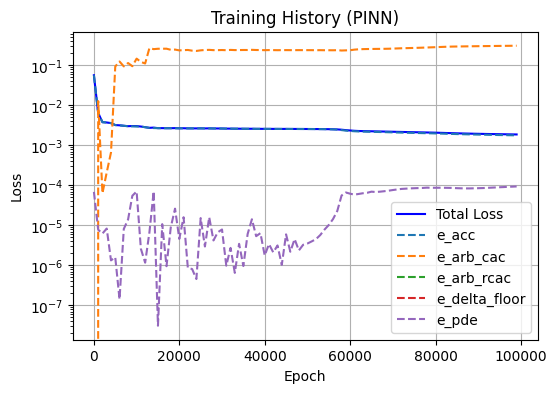

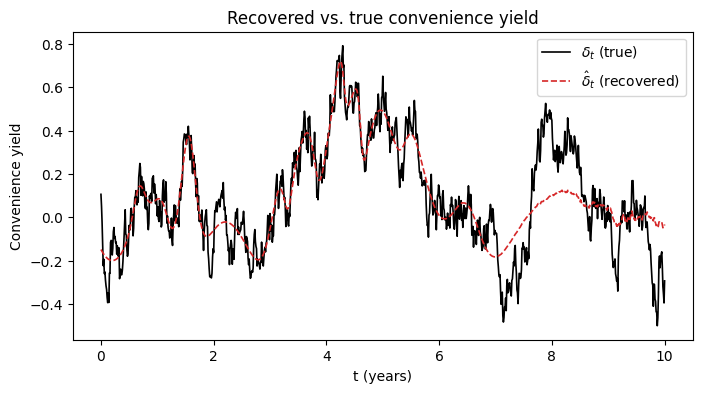

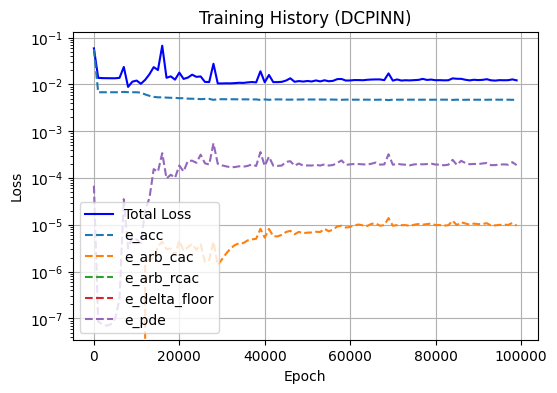

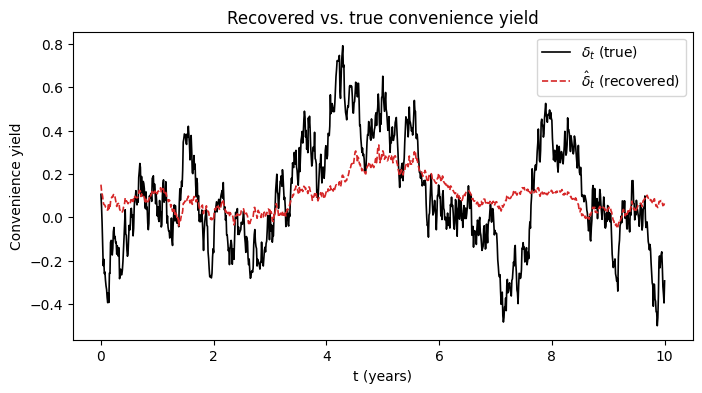

In [21]:
def plot_training_history(history_path, save_path=None):
    """Plot training loss history"""
    with open(history_path, 'rb') as f:
        results = pickle.load(f)
    history = results['history']

    epochs, losses, metrics = zip(*history)

    fig, ax = plt.subplots(1, 1, figsize=(6, 4))
    ax.plot(epochs, losses, 'b-', label='Total Loss')

    for key in metrics[0].keys():
        metric_values = [m[key] for m in metrics]
        ax.plot(epochs, metric_values, '--', label=key)

    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_yscale('log')
    ax.grid(True)
    ax.legend()
    plt.title(f"Training History ({results['config'].loss_str})")

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()


def plot_delta_recovery(model, t, S, delta_true, save_path=None):
    """Recovered delta_hat(t, S) vs. the true (eval-only) delta_t path."""
    delta_hat = vmap(lambda tt, SS: model(jnp.array([tt, SS]))[0])(t, S)

    fig, ax = plt.subplots(1, 1, figsize=(8, 4))
    ax.plot(t, delta_true, color='black', lw=1.2, label=r'$\delta_t$ (true)')
    ax.plot(t, delta_hat, color='tab:red', lw=1.2, ls='--', label=r'$\hat{\delta}_t$ (recovered)')
    ax.set_xlabel('t (years)')
    ax.set_ylabel('Convenience yield')
    ax.legend()
    ax.set_title('Recovered vs. true convenience yield')

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()


os.makedirs('figures', exist_ok=True)

plot_training_history('results_PINN.pkl', 'figures/training_history_PINN.png')
plot_delta_recovery(model_PINN, t_train, S_train, delta_true, 'figures/delta_recovery_PINN.png')

plot_training_history('results_DCPINN.pkl', 'figures/training_history_DCPINN.png')
plot_delta_recovery(model_DCPINN, t_train, S_train, delta_true, 'figures/delta_recovery_DCPINN.png')